# Bout PSTH analysis

This notebook plots **z-scored PSTHs** for three bout-frequency measures:

1. **All bouts**
2. **Asymmetric bouts** (`asymmetric_bout == True`)
3. **Straight bouts** (`asymmetric_bout == False`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval
from scipy.stats import circmean

plt.rcParams["figure.dpi"] = 120

## Configuration

Update the two CSV paths if needed. The rest of the notebook should run without changes.

In [2]:
# -----------------------------
# Input paths
# -----------------------------
fb_path = "/Volumes/LaCie/larval_HuC/behavior/7dpf_fb_behavior_traces_posture.csv"
hb_path = "/Volumes/LaCie/larval_HuC/behavior/7dpf_hb_behavior_traces_posture.csv"

# -----------------------------
# Experiment settings
# -----------------------------
sampling_freq = 60.85
stim_onset = 3180  # frame where stimulus starts; change to 3225 if needed

pre_stimulus_seconds = 20
post_stimulus_seconds = 40
bin_size_seconds = 3

key_stimuli = (
    "ade",
    "cad_2.5mm",
    "ph4.5",
    "qui_2.5mm",
    "fex1",
    "kw",
    "pro_2.5mm",
)

stimulus_labels = {
    "ade": "Ade",
    "cad_2.5mm": "Cad",
    "fex1": "Fex",
    "kw": "Kin",
    "ph4.5": "HCl",
    "qui_2.5mm": "Qun",
    "pro_2.5mm": "Pro",
}

stimulus_order = ["Fex", "Kin", "Pro", "Ade", "Cad", "HCl", "Qun"]

stimulus_colors = {
    "Fex": "limegreen",
    "Kin": "forestgreen",
    "Pro": "olive",
    "Ade": "plum",
    "Cad": "mediumorchid",
    "HCl": "fuchsia",
    "Qun": "deeppink",
}

## Load and prepare behavior data

This follows the structure of the original notebooks:

- standardize `fish_id`
- parse `angles` and `bouts`
- create `bout_indx`
- create `fish_id_clean`
- classify bouts as asymmetric/straight if `asymmetric_bout` is not already present

In [3]:
def safe_literal_eval(x):
    """Parse stringified lists while leaving already-parsed lists unchanged."""
    if isinstance(x, str):
        return literal_eval(x)
    return x


def load_behavior_data(path, suffix):
    df = pd.read_csv(path)
    df["fish_id"] = df["fish_id"].astype(str) + suffix

    if "angles" in df.columns:
        df["angles"] = df["angles"].apply(safe_literal_eval)

    if "bout_indx" not in df.columns:
        if "bouts" not in df.columns:
            raise ValueError("Could not find either 'bout_indx' or 'bouts' column.")
        df["bout_indx"] = df["bouts"].apply(safe_literal_eval)
    else:
        df["bout_indx"] = df["bout_indx"].apply(safe_literal_eval)

    return df


def classify_asymm_bouts(
    row,
    left_threshold=-0.06,
    right_threshold=0.06,
    sampling_rate=60.85,
    duration_ms=70,
):
    """
    Classify each bout as left/right/straight using the circular mean of tail angles
    in the first duration_ms after bout onset.
    """
    asymmetric_flags = []
    directions = []

    bouts = row["bout_indx"]
    tail_angle = row["angles"]
    duration_frames = int((duration_ms / 1000) * sampling_rate)

    for bout in bouts:
        if len(bout) < 1:
            continue

        bout_start = bout[0]
        bout_duration = min(duration_frames, len(bout))
        angles = np.asarray(tail_angle[bout_start:bout_start + bout_duration])

        if len(angles) == 0:
            asymmetric_flags.append(False)
            directions.append("straight")
            continue

        laterality_index = circmean(angles, high=np.pi, low=-np.pi)

        if laterality_index < left_threshold:
            asymmetric_flags.append(True)
            directions.append("left")
        elif laterality_index > right_threshold:
            asymmetric_flags.append(True)
            directions.append("right")
        else:
            asymmetric_flags.append(False)
            directions.append("straight")

    return pd.Series([asymmetric_flags, directions])

In [4]:
# Load forebrain and hindbrain data
bhv_fb = load_behavior_data(fb_path, "_fb")
bhv_hb = load_behavior_data(hb_path, "_hb")

bhv = pd.concat([bhv_fb, bhv_hb], ignore_index=True)

# Keep key stimuli only
stimulus_df = bhv[bhv["stimulus"].isin(key_stimuli)].copy()

# Clean fish IDs across fb/hb sessions
stimulus_df["fish_id_clean"] = (
    stimulus_df["fish_id"]
    .astype(str)
    .str.replace(r"(_fb|_hb)$", "", regex=True)
)

stimulus_df["session"] = (
    stimulus_df["fish_id"]
    .astype(str)
    .str.extract(r"(fb|hb)", expand=False)
)

# Create asymmetric_bout and bout_direction if needed
if "asymmetric_bout" not in stimulus_df.columns:
    if "angles" not in stimulus_df.columns:
        raise ValueError("Need 'angles' column to classify asymmetric bouts.")
    stimulus_df[["asymmetric_bout", "bout_direction"]] = stimulus_df.apply(
        lambda row: classify_asymm_bouts(
            row,
            left_threshold=-0.06,
            right_threshold=0.06,
            sampling_rate=sampling_freq,
            duration_ms=70,
        ),
        axis=1,
    )
else:
    stimulus_df["asymmetric_bout"] = stimulus_df["asymmetric_bout"].apply(safe_literal_eval)

print("Rows:", len(stimulus_df))
print("Fish:", stimulus_df["fish_id_clean"].nunique())
print("Stimuli:", sorted(stimulus_df["stimulus"].unique()))
stimulus_df.head()

Rows: 420
Fish: 10
Stimuli: ['ade', 'cad_2.5mm', 'fex1', 'kw', 'ph4.5', 'pro_2.5mm', 'qui_2.5mm']


,Unnamed: 0,angles,bouts,fish_id,stimulus,trial_number,posture_movement,bout_indx,fish_id_clean,session,asymmetric_bout,bout_direction
0,0,"[0.006940582264268705, 0.006940582264268705, 0...","[[254, 255, 256, 257, 258, 259, 260, 261, 262,...",230713_fb,ade,1,False,"[[254, 255, 256, 257, 258, 259, 260, 261, 262,...",230713,fb,"[True, True, True, True, True, False, True, Tr...","[left, left, right, right, right, straight, ri..."
1,1,"[0.012481097321293821, 0.0036891981422997877, ...","[[115, 116, 117, 118, 119, 120, 121, 122, 123,...",230713_fb,ade,2,False,"[[115, 116, 117, 118, 119, 120, 121, 122, 123,...",230713,fb,"[True, True, True, True, True, True, True, Tru...","[left, left, left, left, left, left, left, lef..."
2,2,"[0.005006214714176477, 0.005006214714176477, 0...","[[62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, ...",230713_fb,ade,3,False,"[[62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, ...",230713,fb,"[True, True, True, True, True, True, True, Tru...","[left, left, left, left, left, left, left, lef..."
3,3,"[0.005956918958253926, 0.005956918958253926, 0...","[[451, 452, 453, 454, 455, 456, 457, 458, 459,...",230713_fb,cad_2.5mm,1,True,"[[451, 452, 453, 454, 455, 456, 457, 458, 459,...",230713,fb,"[True, True, False, True, False, False, False,...","[left, left, straight, left, straight, straigh..."
4,4,"[0.0029283523002522766, 0.0029283523002522766,...","[[169, 170, 171, 172, 173, 174, 175, 176, 177,...",230713_fb,cad_2.5mm,2,True,"[[169, 170, 171, 172, 173, 174, 175, 176, 177,...",230713,fb,"[True, True, True, True, True, True, True, Tru...","[left, left, left, left, left, left, left, lef..."


## PSTH helper functions

`bout_type` can be:

- `"all"`
- `"asymmetric"`
- `"straight"`

For straight bouts, the function uses `asymmetric_bout == False`, which keeps it directly matched to the asymmetric-bout classification.

In [5]:
def get_selected_bouts(row, bout_type):
    """Return bouts selected according to bout_type."""
    bouts = row["bout_indx"]

    if bout_type == "all":
        return bouts

    if "asymmetric_bout" not in row.index:
        raise ValueError("Need 'asymmetric_bout' column for asymmetric/straight PSTHs.")

    asymmetric_flags = row["asymmetric_bout"]

    if bout_type == "asymmetric":
        return [bout for bout, is_asym in zip(bouts, asymmetric_flags) if is_asym]

    if bout_type == "straight":
        return [bout for bout, is_asym in zip(bouts, asymmetric_flags) if not is_asym]

    raise ValueError("bout_type must be one of: 'all', 'asymmetric', 'straight'.")


def build_psth_histograms(
    stimulus_df,
    bout_type="all",
    stim_onset=3180,
    sampling_freq=60.85,
    pre_stimulus_seconds=20,
    post_stimulus_seconds=40,
    bin_size_seconds=3,
):
    """
    Build per-stimulus histograms of bout counts in fixed time bins.
    Output dataframes have rows = bin starts in seconds, columns = fish_id_clean.
    """
    pre_stimulus_frames = int(pre_stimulus_seconds * sampling_freq)
    post_stimulus_frames = int(post_stimulus_seconds * sampling_freq)
    bin_size_frames = int(bin_size_seconds * sampling_freq)

    frame_bins = np.arange(
        -pre_stimulus_frames,
        post_stimulus_frames + bin_size_frames,
        bin_size_frames,
    )

    time_bins = frame_bins[:-1] / sampling_freq
    bin_width = bin_size_frames / sampling_freq
    time_bin_centres = time_bins + bin_width / 2

    hist_data = {
        stimulus: {}
        for stimulus in stimulus_df["stimulus"].dropna().unique()
    }

    for _, row in stimulus_df.iterrows():
        stimulus = row["stimulus"]
        fish_id = row["fish_id_clean"]
        selected_bouts = get_selected_bouts(row, bout_type)

        relative_frames = [bout[0] - stim_onset for bout in selected_bouts if len(bout) > 0]
        hist, _ = np.histogram(relative_frames, bins=frame_bins)

        if fish_id not in hist_data[stimulus]:
            hist_data[stimulus][fish_id] = np.zeros(len(frame_bins) - 1)

        # Add across trials/session rows belonging to the same fish and stimulus
        hist_data[stimulus][fish_id] += hist

    hist_df_dict = {
        stimulus: pd.DataFrame(hist_data[stimulus], index=time_bins)
        for stimulus in hist_data
    }

    return hist_df_dict, time_bins, time_bin_centres, bin_width


def zscore_psth_histograms(hist_df_dict, baseline_window=(-20, 0)):
    """
    Z-score each fish x stimulus histogram using the pre-stimulus baseline window.
    """
    zscored_hist_data = {}

    for stimulus, hist_df in hist_df_dict.items():
        z_df = pd.DataFrame(index=hist_df.index)
        baseline_mask = (hist_df.index >= baseline_window[0]) & (hist_df.index < baseline_window[1])

        for fish_id in hist_df.columns:
            fish_trace = hist_df[fish_id].astype(float)
            baseline_values = fish_trace.loc[baseline_mask]
            baseline_mean = baseline_values.mean()
            baseline_std = baseline_values.std(ddof=1)

            # Avoid division by zero. If baseline has no variation, this fish/stimulus cannot be z-scored reliably.
            if pd.isna(baseline_std) or baseline_std == 0:
                z_df[fish_id] = np.nan
            else:
                z_df[fish_id] = (fish_trace - baseline_mean) / baseline_std

        zscored_hist_data[stimulus] = z_df

    return zscored_hist_data


def summarize_psth(zscored_hist_data):
    """Return mean and SEM per stimulus."""
    mean_data = {
        stimulus: df.mean(axis=1, skipna=True)
        for stimulus, df in zscored_hist_data.items()
    }
    sem_data = {
        stimulus: df.sem(axis=1, skipna=True)
        for stimulus, df in zscored_hist_data.items()
    }
    return mean_data, sem_data

## Plotting functions

In [6]:
def add_stimulus_gradient(ax, xmin=0, xmax=20, ymin=-3, ymax=8):
    """Optional stimulus gradient background from 0 to 20 s."""
    gradient = np.ones((2, 256, 4))
    gradient[:, :, 0] = 0
    gradient[:, :, 1] = 0
    gradient[:, :, 2] = 0.4
    gradient[:, :, 3] = np.linspace(0.3, 0, 256)
    ax.imshow(
        gradient,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        aspect="auto",
        zorder=-1,
    )


def plot_psth_by_stimulus(
    mean_data,
    sem_data,
    time_bin_centres,
    bin_width,
    ylabel="Bout count (z-scored)",
    title_prefix="",
    xlim=(-20, 32),
    ylim=(-2, 9),
    show_gradient=True,
    show_stim_bar=True,
    save_dir=None,
    file_prefix="psth",
):
    """Plot one bar PSTH per stimulus."""
    for stimulus, mean_trace in mean_data.items():
        stimulus_label = stimulus_labels.get(stimulus, stimulus)
        sem_trace = sem_data[stimulus]
        color = stimulus_colors.get(stimulus_label, "darkgrey")

        fig, ax = plt.subplots(figsize=(8, 6))

        ax.bar(
            time_bin_centres,
            mean_trace.values,
            yerr=sem_trace.values,
            width=bin_width,
            color=color,
            alpha=0.8,
            align="center",
            error_kw=dict(ecolor="grey", elinewidth=1.5, capsize=3, capthick=1),
        )

        ax.axhline(y=0, color="red", linestyle="--", linewidth=2)

        if show_gradient:
            add_stimulus_gradient(ax, xmin=0, xmax=20, ymin=ylim[0], ymax=ylim[1])

        if show_stim_bar:
            ax.hlines(y=ylim[1] - 1, xmin=0, xmax=10, colors="black", linewidth=4)

        ax.set_title(f"{title_prefix}{stimulus_label}", fontsize=28, weight="bold", loc="left", pad=20)
        ax.set_xlabel("Time relative to stimulus onset (s)", fontsize=26)
        ax.set_ylabel(ylabel, fontsize=28)
        ax.set_xticks([-20, -10, 0, 10, 20, 30])
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        ax.tick_params(axis="both", which="major", length=4, width=2, direction="out", labelsize=28)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.5)
        ax.spines["bottom"].set_linewidth(1.5)

        plt.tight_layout()

        if save_dir is not None:
            from pathlib import Path
            save_path = Path(save_dir) / f"{file_prefix}_{stimulus}_zscored_PSTH.svg"
            fig.savefig(save_path, format="svg", dpi=300, bbox_inches="tight")
            print("Saved:", save_path)

        plt.show()


def run_and_plot_psth(
    stimulus_df,
    bout_type,
    ylabel,
    title_prefix="",
    ylim=(-2, 9),
    save_dir=None,
):
    """Full PSTH pipeline for one bout type."""
    hist_df_dict, time_bins, time_bin_centres, bin_width = build_psth_histograms(
        stimulus_df=stimulus_df,
        bout_type=bout_type,
        stim_onset=stim_onset,
        sampling_freq=sampling_freq,
        pre_stimulus_seconds=pre_stimulus_seconds,
        post_stimulus_seconds=post_stimulus_seconds,
        bin_size_seconds=bin_size_seconds,
    )

    zscored_hist_data = zscore_psth_histograms(
        hist_df_dict,
        baseline_window=(-pre_stimulus_seconds, 0),
    )

    mean_data, sem_data = summarize_psth(zscored_hist_data)

    plot_psth_by_stimulus(
        mean_data=mean_data,
        sem_data=sem_data,
        time_bin_centres=time_bin_centres,
        bin_width=bin_width,
        ylabel=ylabel,
        title_prefix=title_prefix,
        ylim=ylim,
        save_dir=save_dir,
        file_prefix=bout_type,
    )

    return {
        "hist_df_dict": hist_df_dict,
        "zscored_hist_data": zscored_hist_data,
        "mean_data": mean_data,
        "sem_data": sem_data,
        "time_bins": time_bins,
        "time_bin_centres": time_bin_centres,
        "bin_width": bin_width,
    }

## 1. All-bout frequency PSTHs

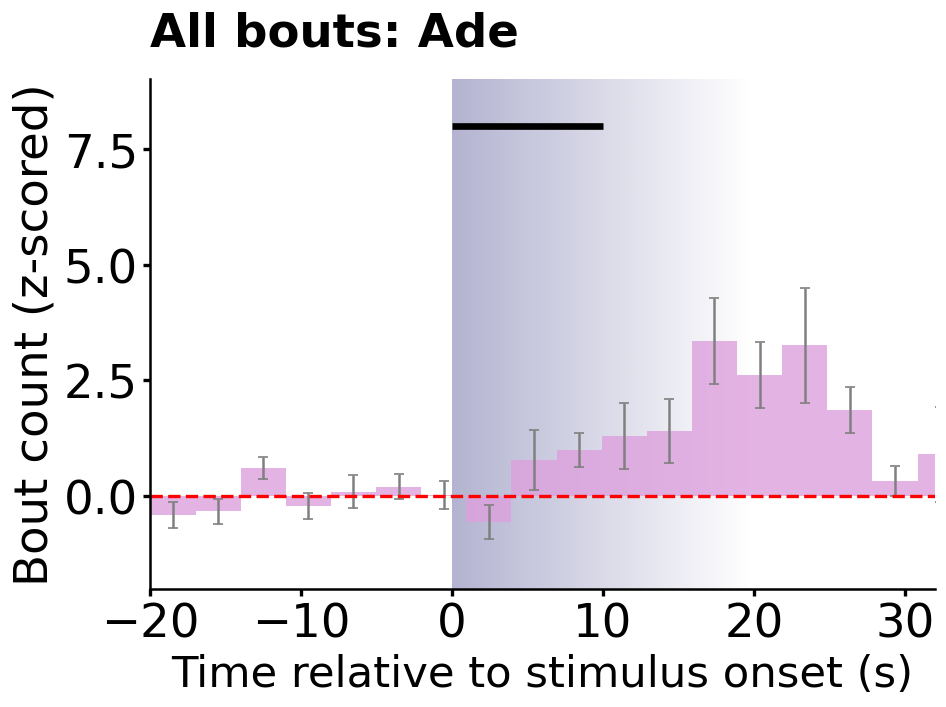

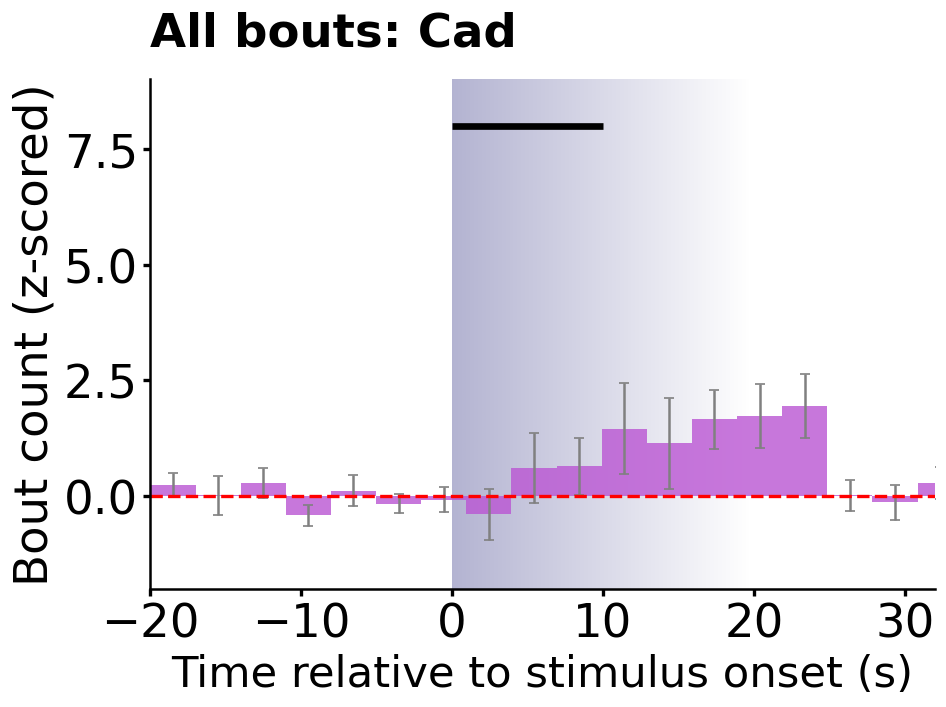

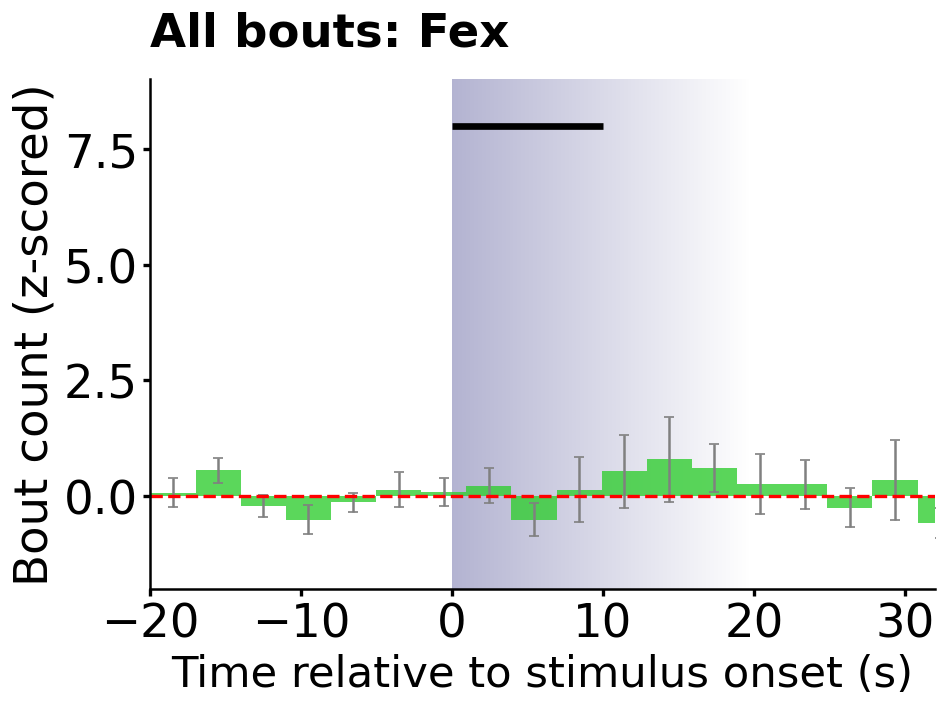

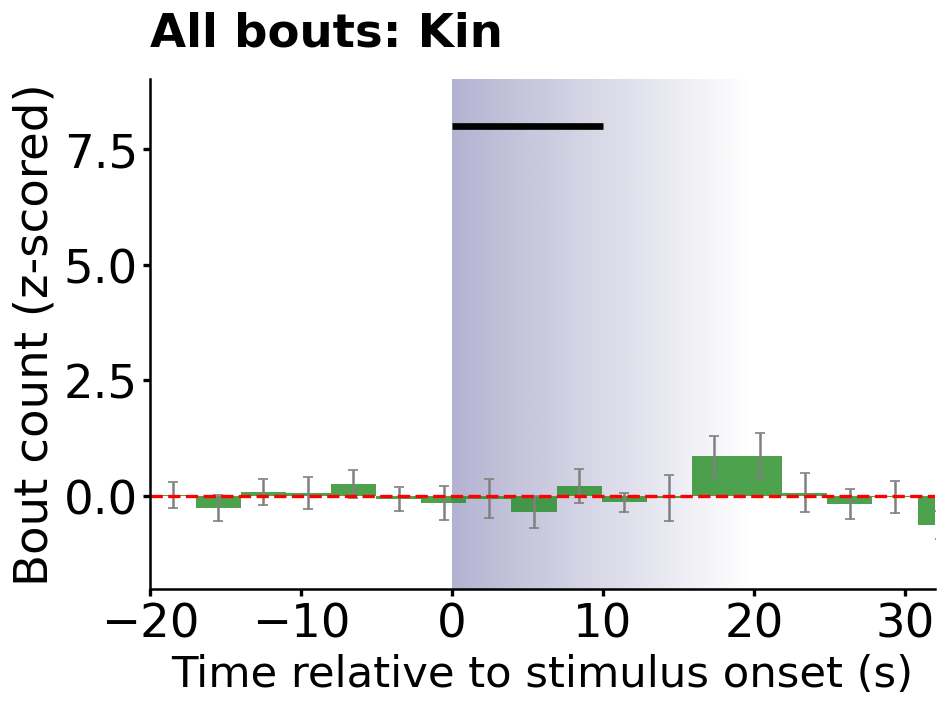

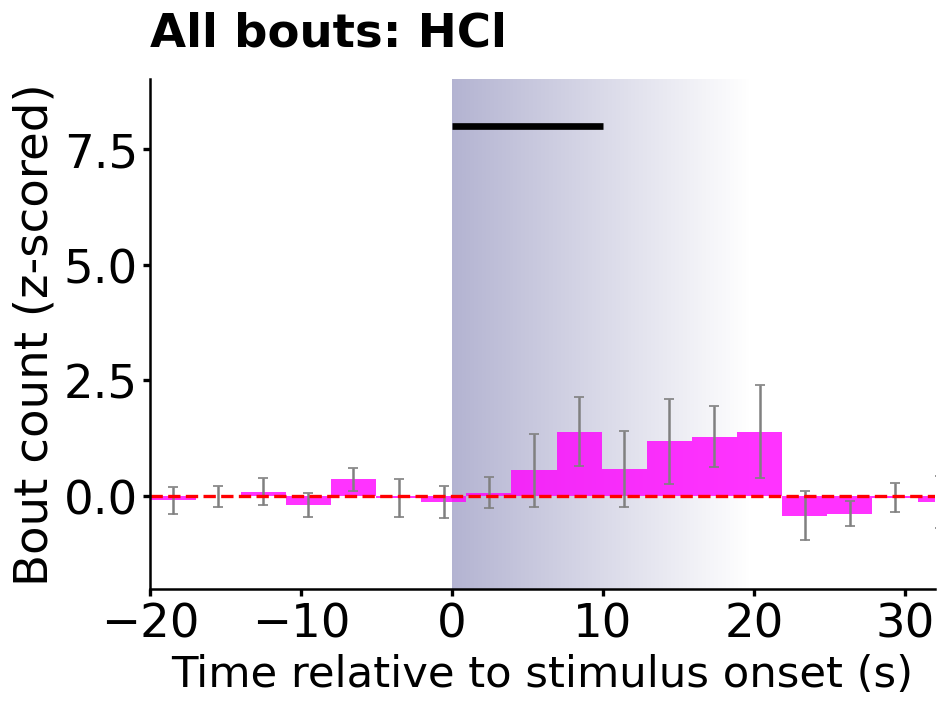

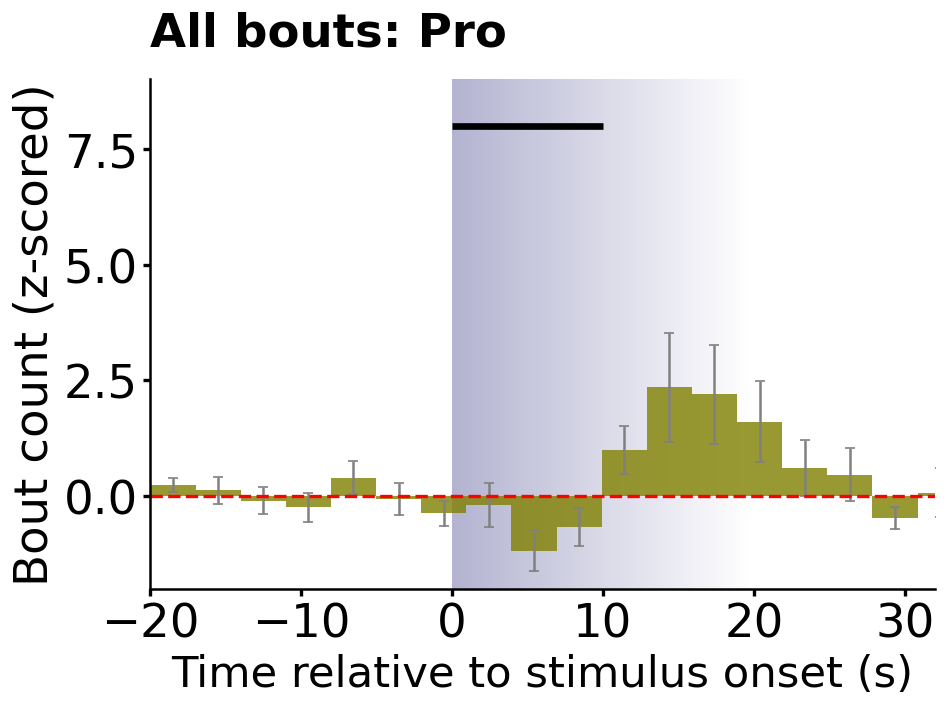

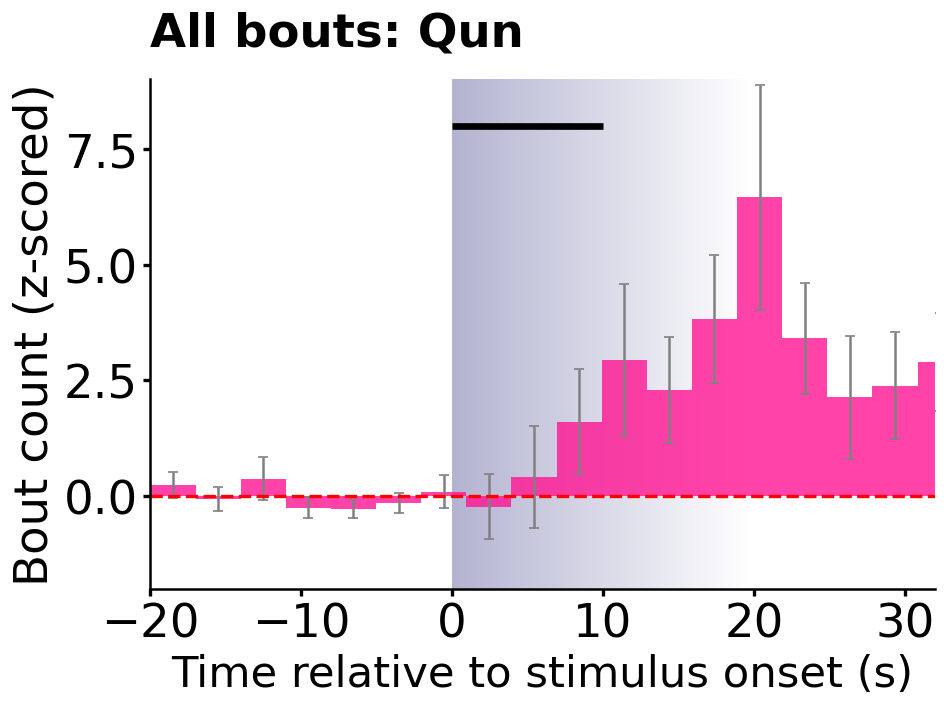

In [9]:
all_bout_results = run_and_plot_psth(
    stimulus_df=stimulus_df,
    bout_type="all",
    ylabel="Bout count (z-scored)",
    title_prefix="All bouts: ",
    ylim=(-2, 9),
    save_dir=None,  # set to a folder path to save SVGs
)

## 2. Asymmetric-bout frequency PSTHs

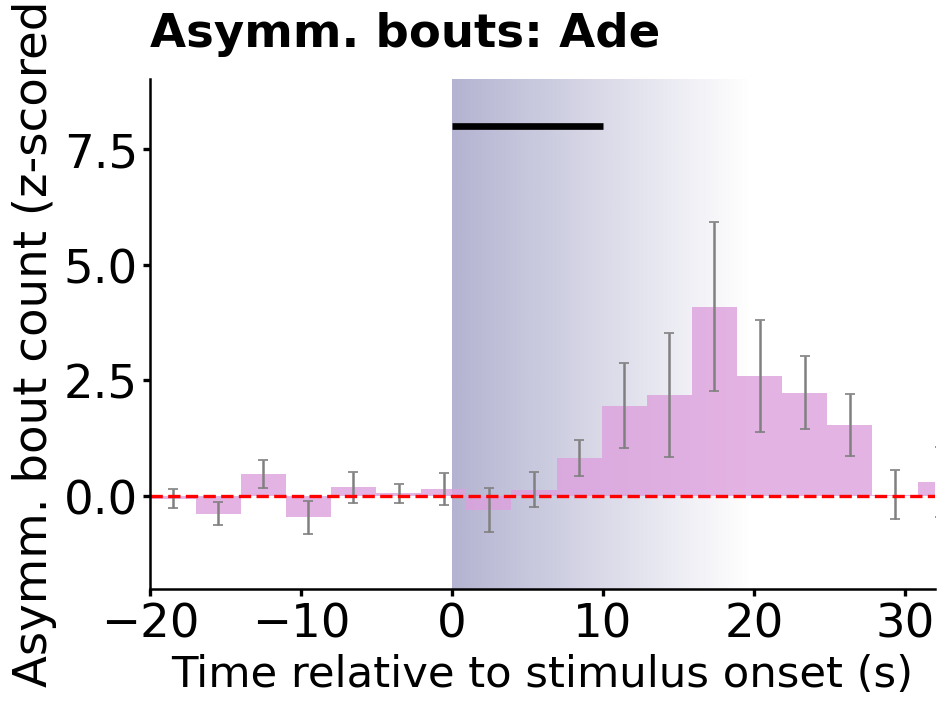

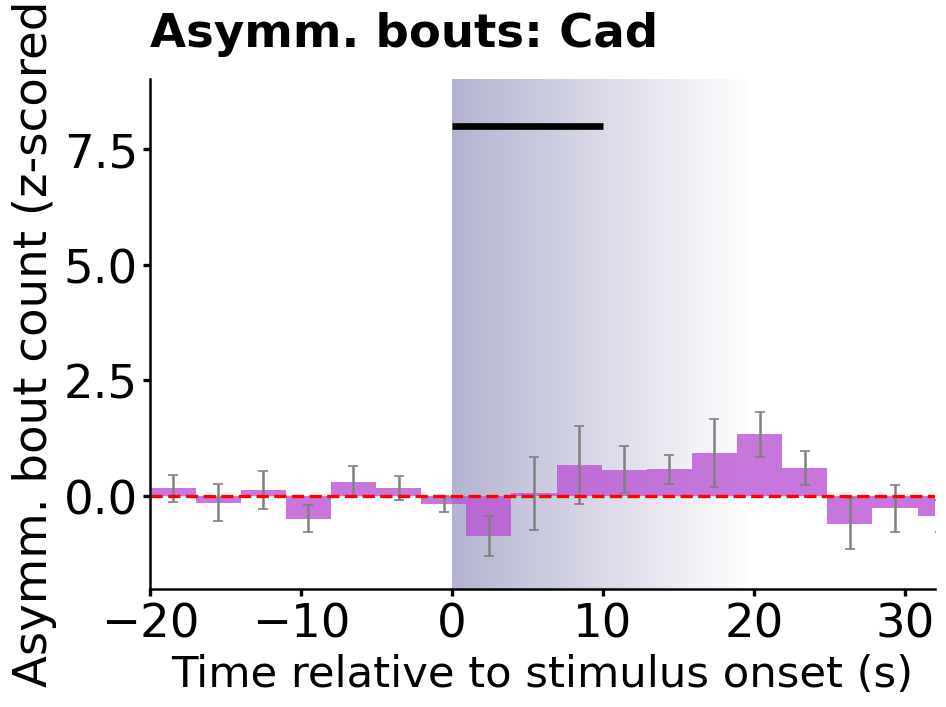

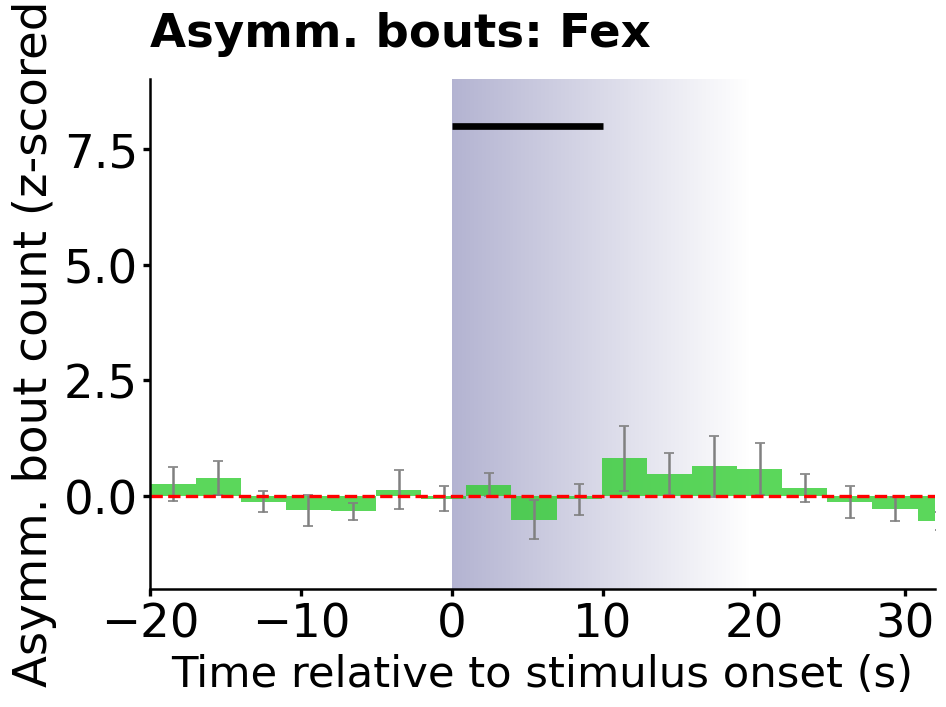

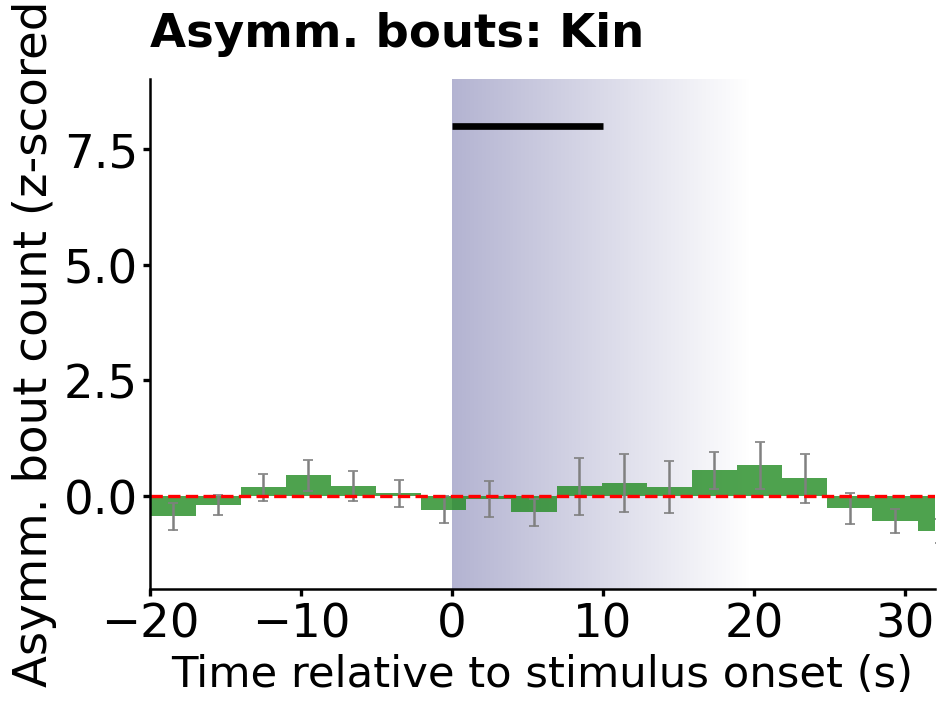

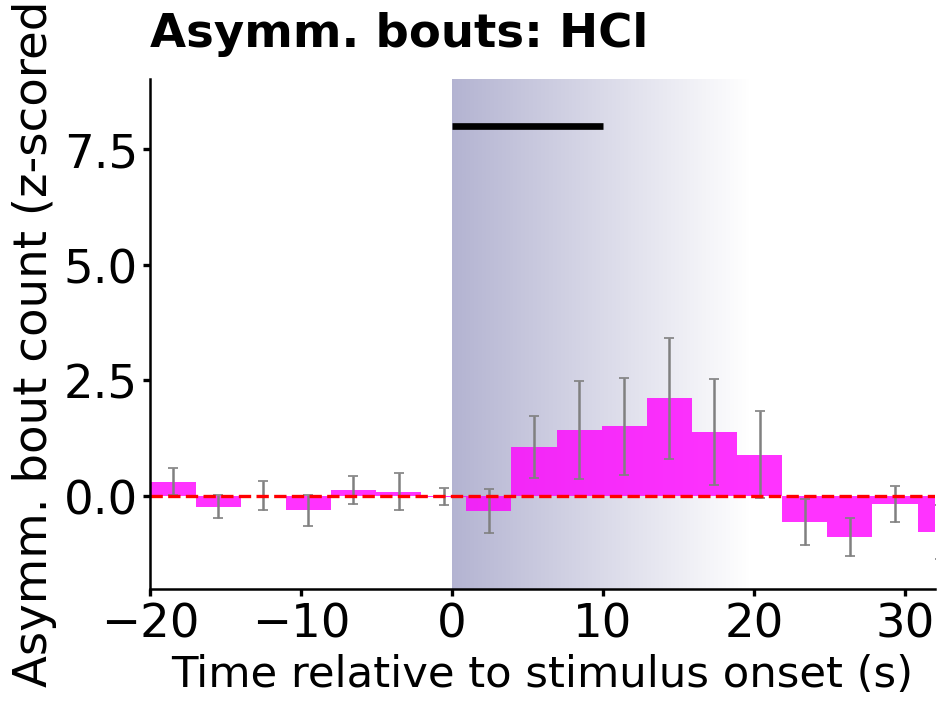

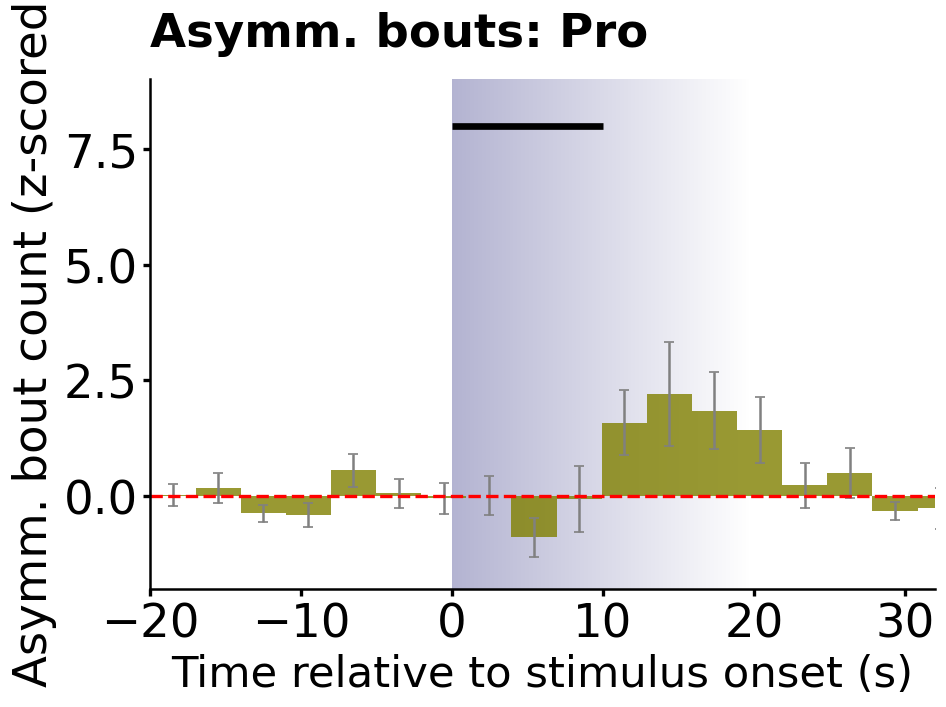

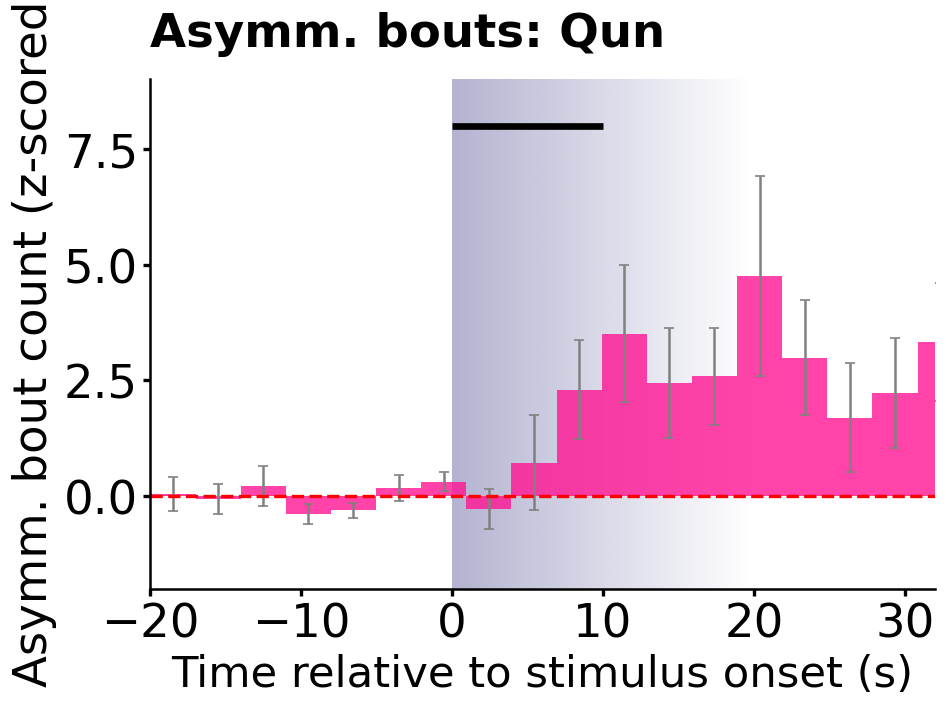

In [13]:
asymmetric_bout_results = run_and_plot_psth(
    stimulus_df=stimulus_df,
    bout_type="asymmetric",
    ylabel="Asymm. bout count (z-scored)",
    title_prefix="Asymm. bouts: ",
    ylim=(-2, 9),
    save_dir=None,
)

## 3. Straight-bout frequency PSTHs

Straight bouts are selected using `asymmetric_bout == False`.

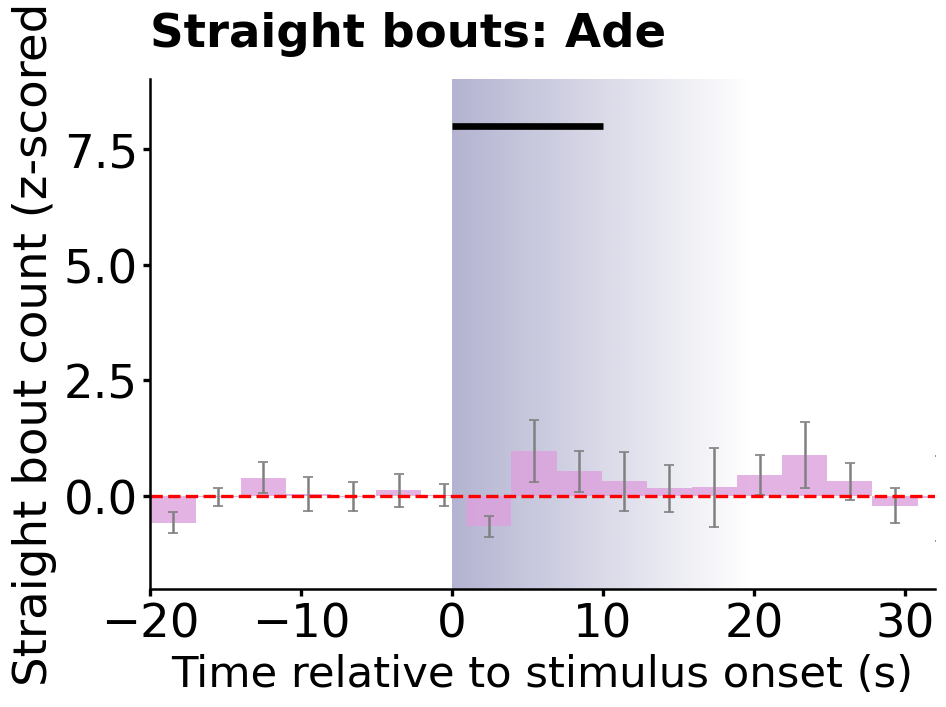

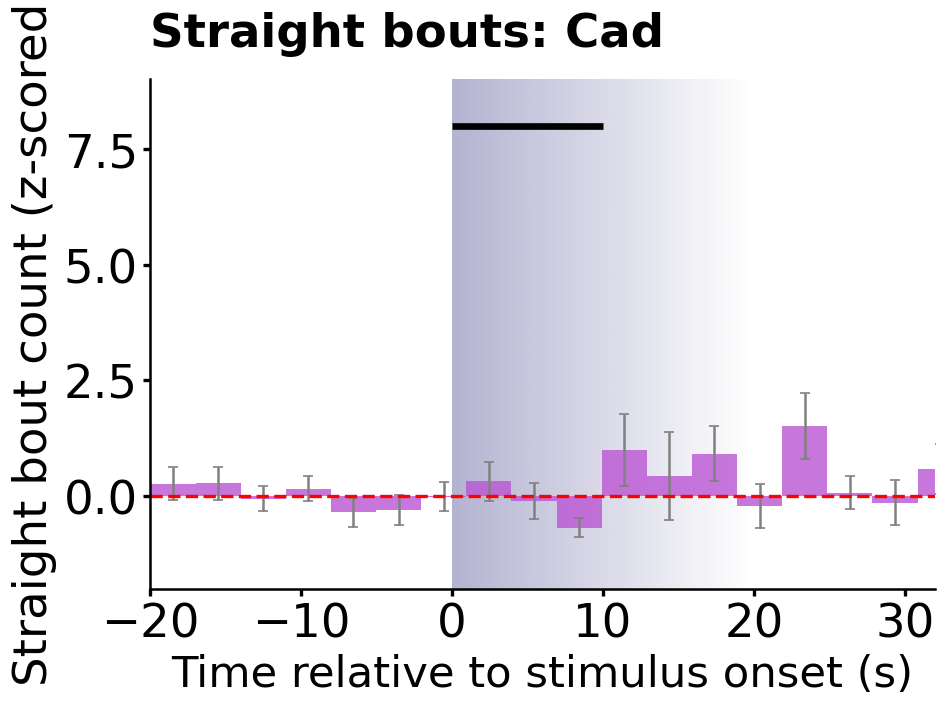

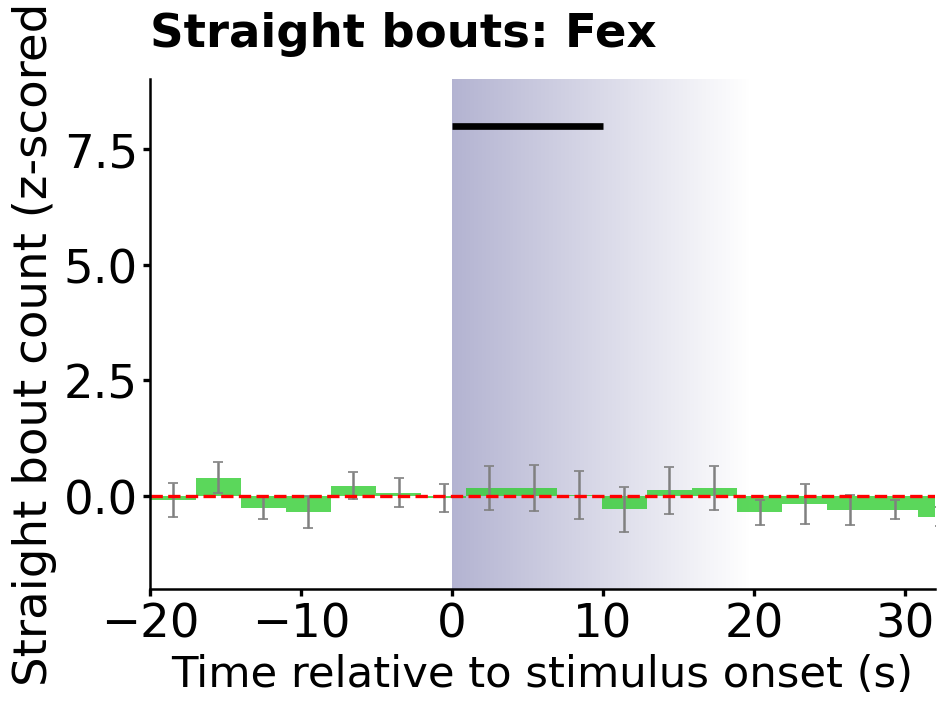

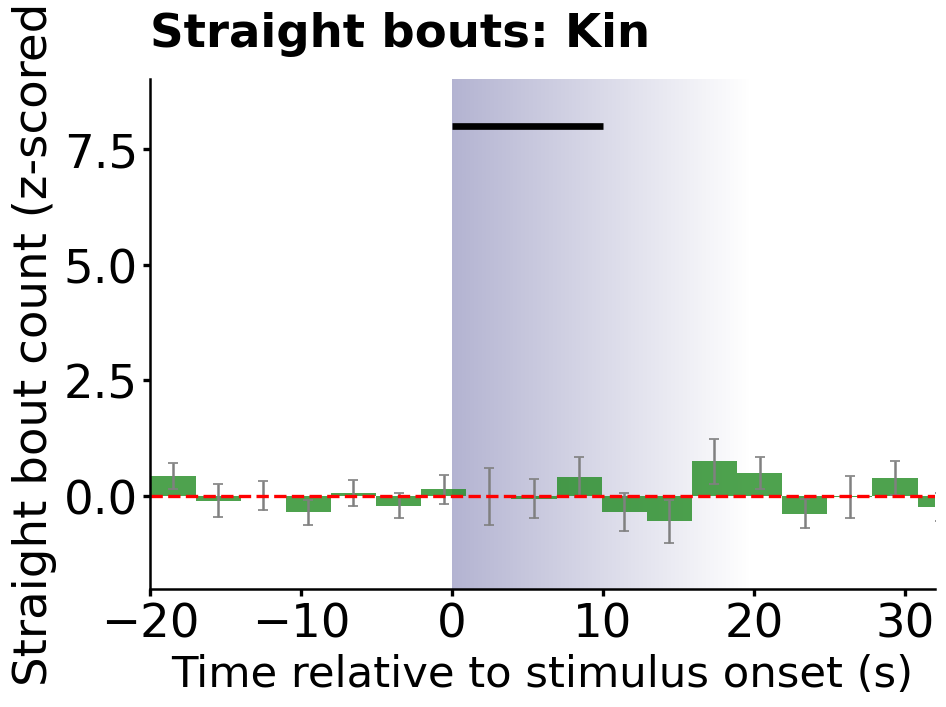

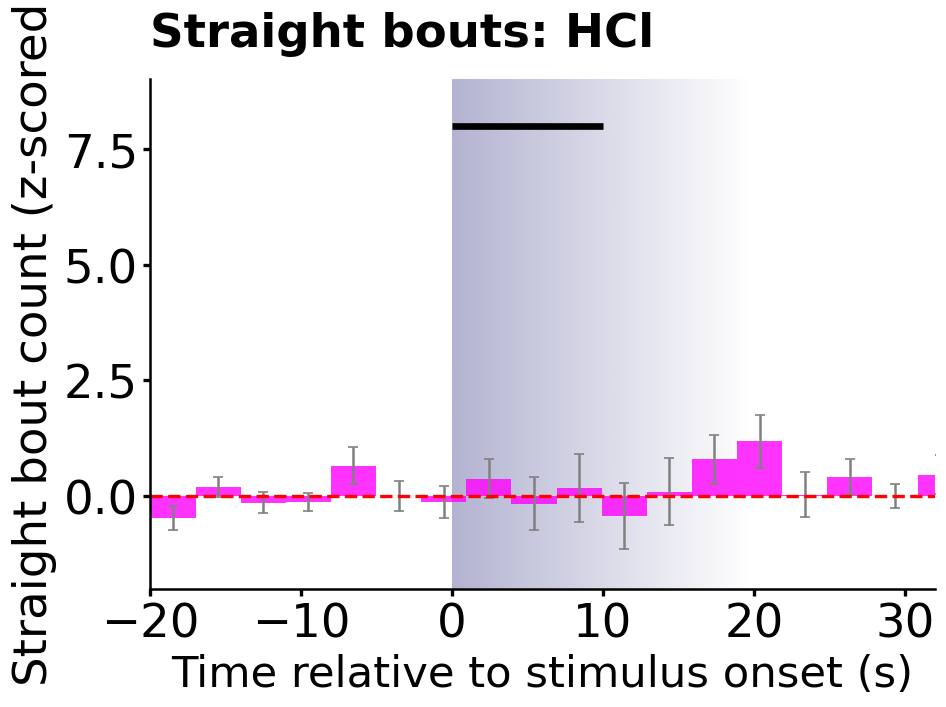

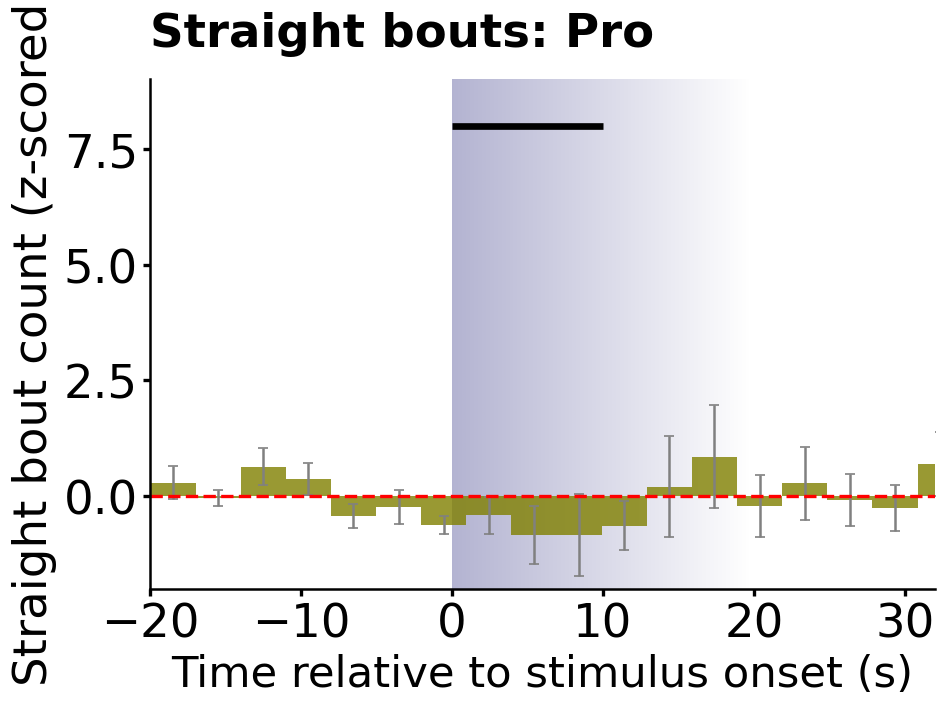

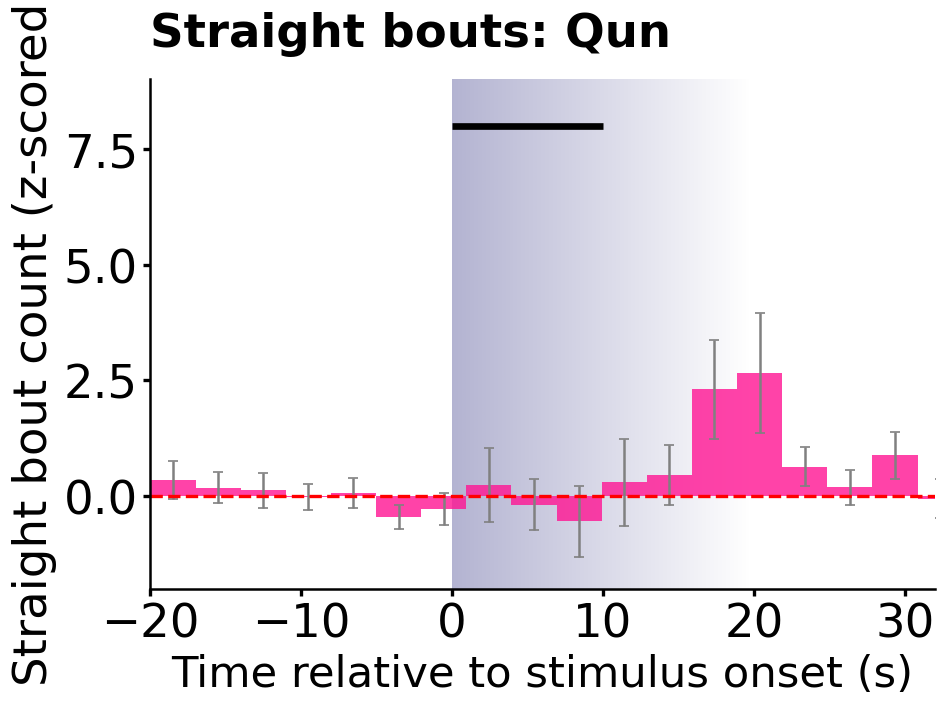

In [9]:
straight_bout_results = run_and_plot_psth(
    stimulus_df=stimulus_df,
    bout_type="straight",
    ylabel="Straight bout count (z-scored)",
    title_prefix="Straight bouts: ",
    ylim=(-2, 9),
    save_dir=None,
)

## Optional: inspect output data

Each result dictionary contains the raw histogram data, z-scored data, mean/SEM traces, and time bins.

In [107]:
print(all_bout_results.keys())

# Example: z-scored PSTH dataframe for one stimulus
example_stim = "fex1"
all_bout_results["zscored_hist_data"][example_stim].head()

dict_keys(['hist_df_dict', 'zscored_hist_data', 'mean_data', 'sem_data', 'time_bins', 'time_bin_centres', 'bin_width'])


,230713,230714,230720,230727,230728,230810,230811,230817,230818,230919
-20.000000,0.866025,0.283473,-0.58554,0.190982,-0.569803,0.637193,1.606349,0.869856,-1.610235,-0.940634
-17.009039,0.866025,-1.039402,-0.58554,1.527857,1.025645,0.637193,0.283473,0.869856,0.439155,1.528531
-14.018077,-0.866025,-0.377964,-0.58554,-1.145893,-0.569803,-0.106199,-0.377964,-0.271830,1.463850,0.705476
-11.027116,-1.732051,-0.377964,1.46385,-1.145893,-0.569803,-0.849591,-0.377964,-1.794079,0.439155,-0.117579
-8.036154,0.000000,0.944911,-0.58554,0.190982,-0.569803,-0.106199,0.944911,-0.652392,-0.585540,-0.940634


## Appetitive vs aversive trajectory analysis

For each fish, appetitive stimuli are averaged together and aversive stimuli are averaged together. The plotted traces are baseline-normalised using the 20 s pre-stimulus window. Significance is calculated with a paired Wilcoxon signed-rank test comparing each time bin against that fish's own 20 s baseline.

In [31]:
from scipy.stats import wilcoxon

positive_stims = ["fex1", "kw", "pro_2.5mm"]


def compute_valence_trajectory_analysis(
    zscored_hist_data,
    time_bins,
    time_bin_centres,
    positive_stims=positive_stims,
    baseline_window=(-20, 0),
    min_n=5,
):
    """
    Compute appetitive and aversive mean trajectories and Wilcoxon p-values.

    Important:
    - Statistics are done across fish, not fish x stimulus, to avoid pseudoreplication.
    - For each fish, positive/appetitive stimuli are averaged together.
    - For each fish, negative/aversive stimuli are averaged together.
    - Each bin is compared against that fish's own 20 s baseline.
    """
    time_bins = np.asarray(time_bins)
    time_bin_centres = np.asarray(time_bin_centres)

    baseline_mask = (time_bins >= baseline_window[0]) & (time_bins < baseline_window[1])

    fish_ids = sorted(set(
        fish_id
        for df in zscored_hist_data.values()
        for fish_id in df.columns
    ))

    pos_raw_traces = []
    neg_raw_traces = []
    pos_baselines = []
    neg_baselines = []
    pos_fish_ids = []
    neg_fish_ids = []

    for fish_id in fish_ids:
        fish_pos_traces = []
        fish_neg_traces = []

        for stimulus, df in zscored_hist_data.items():
            if fish_id not in df.columns:
                continue

            trace = df[fish_id].values.astype(float)

            if stimulus in positive_stims:
                fish_pos_traces.append(trace)
            else:
                fish_neg_traces.append(trace)

        if len(fish_pos_traces) > 0:
            pos_trace = np.nanmean(fish_pos_traces, axis=0)
            pos_baseline = np.nanmean(pos_trace[baseline_mask])

            if not np.isnan(pos_baseline):
                pos_raw_traces.append(pos_trace)
                pos_baselines.append(pos_baseline)
                pos_fish_ids.append(fish_id)

        if len(fish_neg_traces) > 0:
            neg_trace = np.nanmean(fish_neg_traces, axis=0)
            neg_baseline = np.nanmean(neg_trace[baseline_mask])

            if not np.isnan(neg_baseline):
                neg_raw_traces.append(neg_trace)
                neg_baselines.append(neg_baseline)
                neg_fish_ids.append(fish_id)

    pos_raw_traces = np.asarray(pos_raw_traces, dtype=float)
    neg_raw_traces = np.asarray(neg_raw_traces, dtype=float)
    pos_baselines = np.asarray(pos_baselines, dtype=float)
    neg_baselines = np.asarray(neg_baselines, dtype=float)

    # Baseline-normalised traces for plotting
    pos_norm_traces = pos_raw_traces - pos_baselines[:, None]
    neg_norm_traces = neg_raw_traces - neg_baselines[:, None]

    pos_mean = np.nanmean(pos_norm_traces, axis=0)
    neg_mean = np.nanmean(neg_norm_traces, axis=0)

    pos_sem = np.nanstd(pos_norm_traces, axis=0, ddof=1) / np.sqrt(pos_norm_traces.shape[0])
    neg_sem = np.nanstd(neg_norm_traces, axis=0, ddof=1) / np.sqrt(neg_norm_traces.shape[0])

    pos_p_values = []
    neg_p_values = []

    for i in range(len(time_bins)):
        # Positive/appetitive: paired comparison of bin value vs fish baseline
        pos_vals = pos_raw_traces[:, i]
        pos_mask = ~np.isnan(pos_vals) & ~np.isnan(pos_baselines)

        if np.sum(pos_mask) >= min_n:
            diffs = pos_vals[pos_mask] - pos_baselines[pos_mask]
            if np.allclose(diffs, 0, equal_nan=True):
                pos_p_values.append(np.nan)
            else:
                _, p = wilcoxon(pos_vals[pos_mask], pos_baselines[pos_mask], alternative="two-sided")
                pos_p_values.append(p)
        else:
            pos_p_values.append(np.nan)

        # Negative/aversive: paired comparison of bin value vs fish baseline
        neg_vals = neg_raw_traces[:, i]
        neg_mask = ~np.isnan(neg_vals) & ~np.isnan(neg_baselines)

        if np.sum(neg_mask) >= min_n:
            diffs = neg_vals[neg_mask] - neg_baselines[neg_mask]
            if np.allclose(diffs, 0, equal_nan=True):
                neg_p_values.append(np.nan)
            else:
                _, p = wilcoxon(neg_vals[neg_mask], neg_baselines[neg_mask], alternative="two-sided")
                neg_p_values.append(p)
        else:
            neg_p_values.append(np.nan)

    return {
        "time_bins": time_bins,
        "time_bin_centres": time_bin_centres,
        "bin_width": time_bins[1] - time_bins[0],
        "pos_norm_traces": pos_norm_traces,
        "neg_norm_traces": neg_norm_traces,
        "pos_raw_traces": pos_raw_traces,
        "neg_raw_traces": neg_raw_traces,
        "pos_baselines": pos_baselines,
        "neg_baselines": neg_baselines,
        "pos_fish_ids": pos_fish_ids,
        "neg_fish_ids": neg_fish_ids,
        "pos_mean": pos_mean,
        "neg_mean": neg_mean,
        "pos_sem": pos_sem,
        "neg_sem": neg_sem,
        "pos_p_values": np.asarray(pos_p_values, dtype=float),
        "neg_p_values": np.asarray(neg_p_values, dtype=float),
    }


def plot_valence_trajectory_analysis(
    analysis,
    ylabel="Bout count (z-scored)",
    title=None,
    plot_window=(-10, 30),
    ylim=(-1.5, 5),
    y_star_pos=4.15,
    y_star_neg=4.65,
    show_legend=False,
    save_path=None,
):
    """Plot appetitive and aversive trajectories exactly like the original version."""

    time_bins = analysis["time_bins"]
    bin_width = analysis["bin_width"]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Appetitive
    ax.plot(
        time_bins,
        analysis["pos_mean"],
        color="green",
        linewidth=2,
        label="Appetitive",
    )

    ax.fill_between(
        time_bins,
        analysis["pos_mean"] - analysis["pos_sem"],
        analysis["pos_mean"] + analysis["pos_sem"],
        color="green",
        alpha=0.3,
    )

    # Aversive
    ax.plot(
        time_bins,
        analysis["neg_mean"],
        color="magenta",
        linewidth=2,
        label="Aversive",
    )

    ax.fill_between(
        time_bins,
        analysis["neg_mean"] - analysis["neg_sem"],
        analysis["neg_mean"] + analysis["neg_sem"],
        color="magenta",
        alpha=0.3,
    )

    # Baseline
    ax.axhline(
        0,
        color="lightgrey",
        linestyle="--",
        linewidth=1,
    )

    # Stimulus onset
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
    )

    # Appetitive significance markers
    for t, p in zip(time_bins, analysis["pos_p_values"]):

        x_star = t 

        if x_star < 0 or x_star > plot_window[1] or np.isnan(p):
            continue

        if p < 0.01:
            star = "**"
        elif p < 0.05:
            star = "*"
        else:
            continue

        ax.text(
            x_star,
            y_star_pos,
            star,
            color="green",
            fontsize=18,
            fontweight="bold",
            ha="center",
        )

    # Aversive significance markers
    for t, p in zip(time_bins, analysis["neg_p_values"]):

        x_star = t 

        if x_star < 0 or x_star > plot_window[1] or np.isnan(p):
            continue

        if p < 0.01:
            star = "**"
        elif p < 0.05:
            star = "*"
        else:
            continue

        ax.text(
            x_star,
            y_star_neg,
            star,
            color="magenta",
            fontsize=18,
            fontweight="bold",
            ha="center",
        )

    ax.set_xlim(plot_window)
    ax.set_ylim(ylim)

    ax.set_xlabel("Time relative to stimulus onset (s)", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)

    if title is not None:
        ax.set_title(title, fontsize=18, weight="bold")

    if show_legend:
        ax.legend(frameon=False, fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    ax.tick_params(
        width=1.5,
        length=5,
        labelsize=20,
        direction="out",
    )

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, format="svg", dpi=300, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

    return fig, ax


def run_valence_trajectory_analysis(
    psth_results,
    ylabel="Bout count (z-scored)",
    title=None,
    ylim=(-1.5, 5),
    y_star_pos=4.65,
    y_star_neg=4.15,
    save_path=None,
):
    """Convenience wrapper: compute and plot appetitive/aversive trajectory analysis."""
    analysis = compute_valence_trajectory_analysis(
        zscored_hist_data=psth_results["zscored_hist_data"],
        time_bins=psth_results["time_bins"],
        time_bin_centres=psth_results["time_bin_centres"],
        positive_stims=positive_stims,
        baseline_window=(-pre_stimulus_seconds, 0),
    )

    plot_valence_trajectory_analysis(
        analysis,
        ylabel=ylabel,
        title=title,
        ylim=ylim,
        y_star_pos=y_star_pos,
        y_star_neg=y_star_neg,
        save_path=save_path,
    )

    print("n appetitive fish:", len(analysis["pos_fish_ids"]))
    print("n aversive fish:", len(analysis["neg_fish_ids"]))

    return analysis


### Run appetitive vs aversive trajectory analysis for each bout type

These cells use the PSTH outputs already generated above. Set `save_path` to an SVG filepath if you want to save any plot.

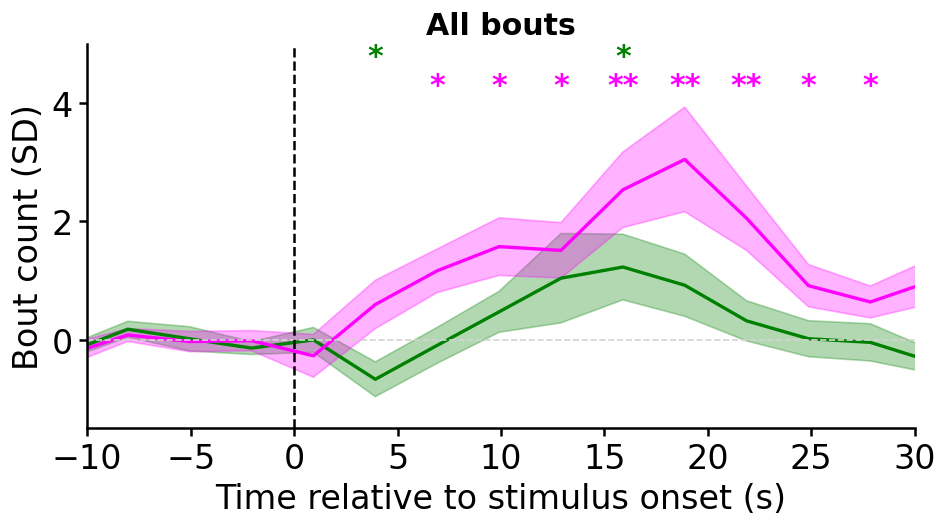

n appetitive fish: 10
n aversive fish: 10


In [32]:
all_bout_valence_analysis = run_valence_trajectory_analysis(
    all_bout_results,
    ylabel="Bout count (SD)",
    title="All bouts",
    ylim=(-1.5, 5),
    y_star_pos=4.65,
    y_star_neg=4.15,
    save_path=None,
)

# "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_sliding_window_pos_vs_neg_all_bout_freq.svg"

In [33]:
results_df = pd.DataFrame({
    "time_bin": all_bout_valence_analysis["time_bins"],
    "pos_mean": all_bout_valence_analysis["pos_mean"],
    "pos_sem": all_bout_valence_analysis["pos_sem"],
    "pos_pvalue": all_bout_valence_analysis["pos_p_values"],
    "neg_mean": all_bout_valence_analysis["neg_mean"],
    "neg_sem": all_bout_valence_analysis["neg_sem"],
    "neg_pvalue": all_bout_valence_analysis["neg_p_values"],
})

display(results_df)

,time_bin,pos_mean,pos_sem,pos_pvalue,neg_mean,neg_sem,neg_pvalue
0,-20.000000,0.115185,0.129273,0.375000,-0.006955,0.139062,0.845703
1,-17.009039,0.141040,0.184669,0.556641,-0.092849,0.164042,0.431641
2,-14.018077,-0.071241,0.157296,0.695312,0.342980,0.234677,0.160156
3,-11.027116,-0.225219,0.110155,0.083984,-0.265399,0.179444,0.275391
4,-8.036154,0.173821,0.134876,0.322266,0.076453,0.109383,0.492188
5,-5.045193,0.011442,0.204346,0.845703,-0.034577,0.171680,0.695312
6,-2.054232,-0.145027,0.108335,0.275391,-0.019652,0.171192,0.921875
7,0.936730,-0.005976,0.210784,1.000000,-0.275780,0.362333,0.695312
8,3.927691,-0.672629,0.294593,0.048828,0.592749,0.409131,0.431641
9,6.918652,-0.098642,0.304163,0.556641,1.163084,0.368471,0.019531


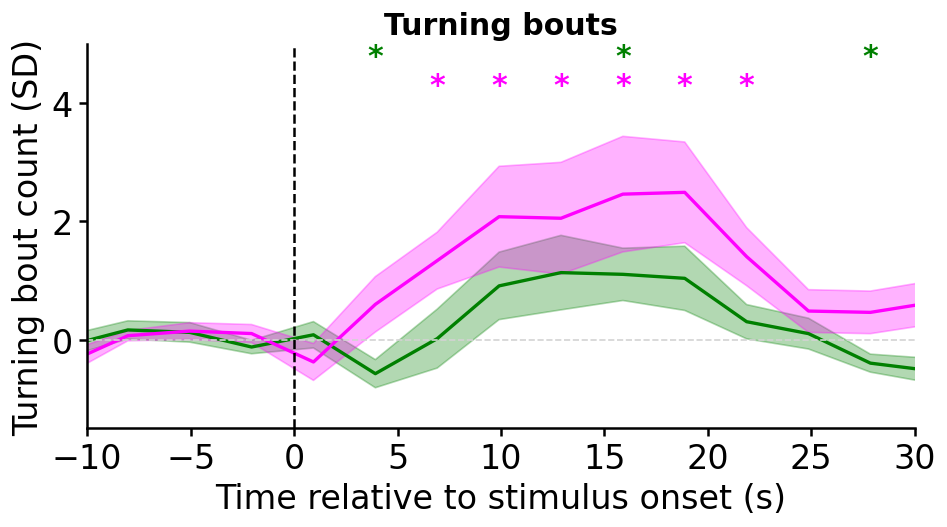

n appetitive fish: 10
n aversive fish: 10


In [14]:
asymmetric_bout_valence_analysis = run_valence_trajectory_analysis(
    asymmetric_bout_results,
    ylabel="Turning bout count (SD)",
    title="Turning bouts",
    ylim=(-1.5, 5),
    y_star_pos=4.65,
    y_star_neg=4.15,
    save_path=None,
)

# "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_sliding_window_pos_vs_neg_turning_bout_freq.svg"

In [15]:
results_df = pd.DataFrame({
    "time_bin": asymmetric_bout_valence_analysis["time_bins"],
    "pos_mean": asymmetric_bout_valence_analysis["pos_mean"],
    "pos_sem": asymmetric_bout_valence_analysis["pos_sem"],
    "pos_pvalue": asymmetric_bout_valence_analysis["pos_p_values"],
    "neg_mean": asymmetric_bout_valence_analysis["neg_mean"],
    "neg_sem": asymmetric_bout_valence_analysis["neg_sem"],
    "neg_pvalue": asymmetric_bout_valence_analysis["neg_p_values"],
})

display(results_df)

,time_bin,pos_mean,pos_sem,pos_pvalue,neg_mean,neg_sem,neg_pvalue
0,-20.000000,-0.056026,0.139245,1.000000,0.095737,0.166350,0.625000
1,-17.009039,0.134895,0.143241,0.275391,-0.215405,0.193340,0.275391
2,-14.018077,-0.122828,0.153726,0.625000,0.219142,0.211683,0.322266
3,-11.027116,-0.111784,0.178480,0.275391,-0.407322,0.194714,0.083984
4,-8.036154,0.161996,0.154571,0.431641,0.064697,0.087317,0.375000
5,-5.045193,0.120849,0.165594,0.492188,0.142422,0.142413,0.431641
6,-2.054232,-0.127102,0.114097,0.375000,0.100729,0.153211,0.431641
7,0.936730,0.079824,0.223118,0.695312,-0.379892,0.312162,0.322266
8,3.927691,-0.577838,0.238313,0.048828,0.594914,0.469244,0.492188
9,6.918652,0.015194,0.498969,0.431641,1.334802,0.480954,0.019531


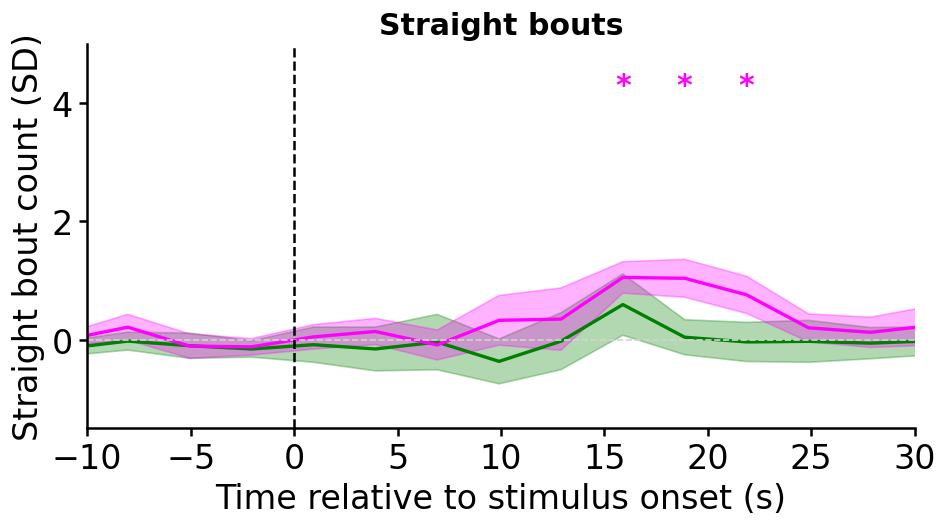

n appetitive fish: 10
n aversive fish: 10


In [113]:
straight_bout_valence_analysis = run_valence_trajectory_analysis(
    straight_bout_results,
    ylabel="Straight bout count (SD)",
    title="Straight bouts",
    ylim=(-1.5, 5),
    y_star_pos=4.65,
    y_star_neg=4.15,
    save_path=None,
)
#"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_sliding_window_pos_vs_neg_straight_bout_freq.svg"

In [114]:
results_df = pd.DataFrame({
    "time_bin": straight_bout_valence_analysis["time_bins"],
    "pos_mean": straight_bout_valence_analysis["pos_mean"],
    "pos_sem": straight_bout_valence_analysis["pos_sem"],
    "pos_pvalue": straight_bout_valence_analysis["pos_p_values"],
    "neg_mean": straight_bout_valence_analysis["neg_mean"],
    "neg_sem": straight_bout_valence_analysis["neg_sem"],
    "neg_pvalue": straight_bout_valence_analysis["neg_p_values"],
})

display(results_df)

,time_bin,pos_mean,pos_sem,pos_pvalue,neg_mean,neg_sem,neg_pvalue
0,-20.000000,0.227937,0.207670,0.431641,-0.168225,0.145762,0.375000
1,-17.009039,0.127766,0.175141,0.556641,0.111188,0.136412,0.695312
2,-14.018077,0.087389,0.151266,0.431641,0.086562,0.152783,0.625000
3,-11.027116,-0.150211,0.126117,0.275391,-0.002677,0.110546,1.000000
4,-8.036154,-0.027187,0.151712,0.845703,0.208321,0.217705,0.625000
5,-5.045193,-0.105237,0.214113,0.431641,-0.111575,0.207050,0.275391
6,-2.054232,-0.160457,0.138509,0.275391,-0.123594,0.139019,0.431641
7,0.936730,-0.087741,0.298027,0.556641,0.044541,0.206984,0.845703
8,3.927691,-0.160032,0.371058,0.556641,0.135968,0.222034,0.625000
9,6.918652,-0.043489,0.469201,0.921875,-0.091685,0.253403,0.769531


### Optional: print p-values

The stars on the plots are based on these p-values. The time points are bin centres.

In [17]:
def print_valence_pvalues(analysis, label):
    print(f"\n{label} — appetitive p-values")
    print(list(zip(analysis["time_bin_centres"], analysis["pos_p_values"])))

    print(f"\n{label} — aversive p-values")
    print(list(zip(analysis["time_bin_centres"], analysis["neg_p_values"])))


print_valence_pvalues(all_bout_valence_analysis, "All bouts")
print_valence_pvalues(asymmetric_bout_valence_analysis, "Asymmetric bouts")
print_valence_pvalues(straight_bout_valence_analysis, "Straight bouts")


All bouts — appetitive p-values
[(np.float64(-18.504519309778143), np.float64(0.375)), (np.float64(-15.513557929334429), np.float64(0.556640625)), (np.float64(-12.522596548890714), np.float64(0.6953125)), (np.float64(-9.531635168447), np.float64(0.083984375)), (np.float64(-6.540673788003286), np.float64(0.322265625)), (np.float64(-3.5497124075595723), np.float64(0.845703125)), (np.float64(-0.5587510271158587), np.float64(0.275390625)), (np.float64(2.4322103533278554), np.float64(1.0)), (np.float64(5.423171733771569), np.float64(0.048828125)), (np.float64(8.414133114215282), np.float64(0.556640625)), (np.float64(11.405094494658998), np.float64(0.275390625)), (np.float64(14.39605587510271), np.float64(0.16015625)), (np.float64(17.387017255546425), np.float64(0.037109375)), (np.float64(20.37797863599014), np.float64(0.16015625)), (np.float64(23.368940016433854), np.float64(0.375)), (np.float64(26.359901396877568), np.float64(1.0)), (np.float64(29.350862777321282), np.float64(0.625)), (np

NameError: name 'straight_bout_valence_analysis' is not defined